In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f3 only
function_folder = os.path.join(base_dir, "function_3")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f3 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 3: shape = {df_f3.shape}, columns = {df_f3.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']


In [3]:
week1_results = {"f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328)}

In [4]:
week2_results = {"f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705)}

In [5]:
week3_results = {"f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815)}

In [6]:
week4_results = {"f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105)}

In [7]:
week5_results = {"f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209)}

In [8]:
week6_results = {"f3": ([0.788392, 0.913423, 0.403090], -0.03637482131814577)}

In [9]:
week7_results = {"f3": ([0.110343, 0.915465, 0.655916], -0.12413097550625916)}

In [10]:
week8_results = {"f3": ([0.394618, 0.003779, 0.001514], -0.18116078744677863)}

In [11]:
week9_results = {"f3": ([0.905262, 0.964713, 0.000892], -0.13042760699767658)}

In [12]:
week10_results = {"f3": ([0.964677, 0.666640, 0.326523], -0.045607638959566356)}

In [13]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
}

output_col = output_cols[0]   # this gives "y3"

# add weekly results to df_f3

for week, results in weekly_results.items():
    
    if "f3" not in results:
        continue
    
    inputs, output = results["f3"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f3
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "y1"]
    )
    
    # append to df_f3
    df_f3 = pd.concat([df_f3, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f3 = df_f3.drop_duplicates(ignore_index=True)

print("updated f3 shape:", df_f3.shape)


updated f3 shape: (25, 4)


In [14]:
print(df_f3)

          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147
20  0.788392  0.913423  0.403090 -0.036375
21  0.110343  0.915465  0.655916 -0.124131
22  0.39461

In [15]:
display(df_f3.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,25.0,0.486773,0.294920,0.046809,0.220549,0.437962,0.688252,0.967200
X2,25.0,0.547565,0.289481,0.003779,0.343917,0.611593,0.725136,0.964713
X3,25.0,0.405411,0.291248,0.000876,0.226300,0.340176,0.580181,0.990882
y1,25.0,-0.103101,0.076994,-0.398926,-0.118048,-0.105965,-0.046947,-0.034835


## Pearson Correlation

f3 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,y1
X1,1.000000,0.239201,-0.087001,0.164288
X2,0.239201,1.000000,-0.132120,0.285643
X3,-0.087001,-0.132120,1.000000,-0.284079
y1,0.164288,0.285643,-0.284079,1.000000


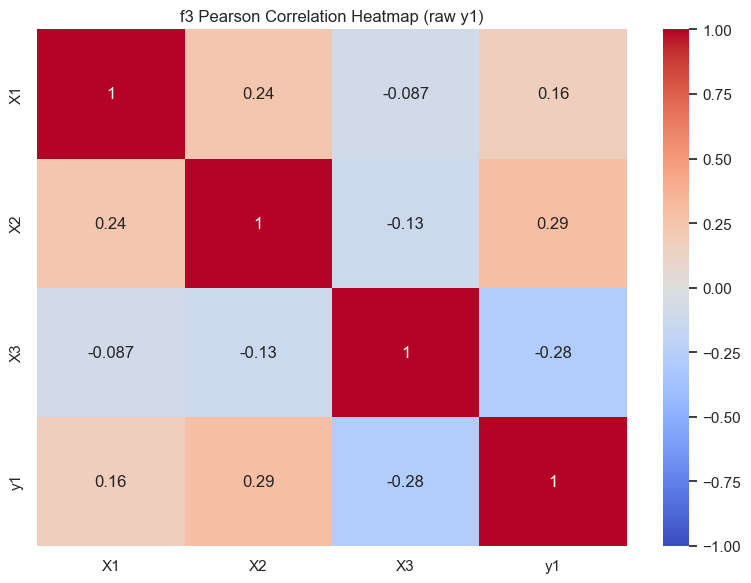

In [16]:
df_raw = df_f3.copy()

print("f3 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f3 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f3 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,y1
X1,1.000000,0.231538,-0.136154,0.091538
X2,0.231538,1.000000,-0.151538,0.246154
X3,-0.136154,-0.151538,1.000000,-0.004615
y1,0.091538,0.246154,-0.004615,1.000000


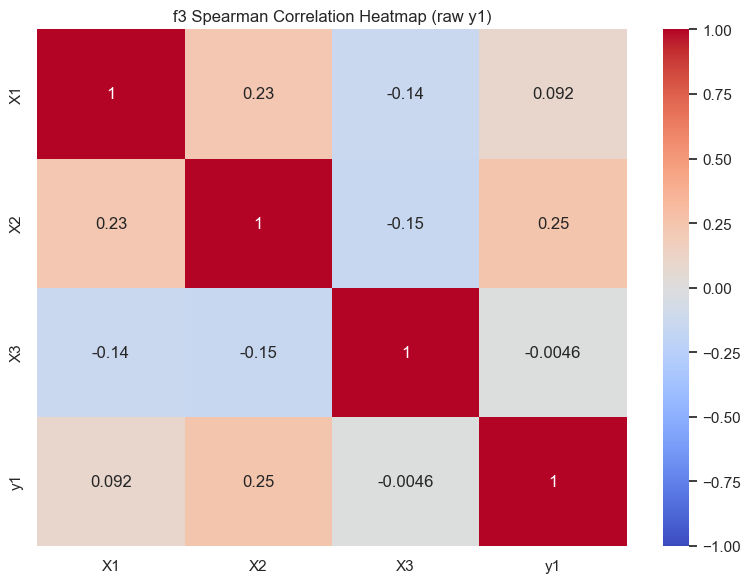

In [17]:
# spearman correlation with raw y1
df_raw = df_f3.copy()

print("f3 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f3 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information with Bootstrapped CI

In [18]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.utils import resample


print("f3 — Mutual Information with Output (Bootstrap 50x)")

# extract X and y
df_f3_raw = df_f3.copy()
input_cols_f3 = [c for c in df_f3_raw.columns if c.startswith("X")]
output_col_f3 = "y1"

X_f3 = df_f3_raw[input_cols_f3].values
y_f3 = df_f3_raw[output_col_f3].values

# base MI estimate
mi_base = mutual_info_regression(X_f3, y_f3, n_neighbors=5, random_state=42)

# bootstrap MI
n_boot = 50
mi_boot = np.zeros((n_boot, len(input_cols_f3)))

for b in range(n_boot):
    Xb, yb = resample(X_f3, y_f3, replace=True, random_state=1000 + b)
    mi_boot[b] = mutual_info_regression(Xb, yb, n_neighbors=5, random_state=2000 + b)

# compute statistics
mi_mean = mi_boot.mean(axis=0)
mi_std = mi_boot.std(axis=0)
mi_se = mi_std / np.sqrt(n_boot)
mi_ci_low = mi_mean - 1.96 * mi_se
mi_ci_high = mi_mean + 1.96 * mi_se

# build dataframe
mi_df = pd.DataFrame({
    "Feature": input_cols_f3,
    "MI_base": mi_base,
    "MI_mean": mi_mean,
    "MI_std": mi_std,
    "MI_SE": mi_se,
    "CI_low": mi_ci_low,
    "CI_high": mi_ci_high
}).sort_values(by="MI_mean", ascending=False)

print("Mutual Information Summary (f3)")
print(mi_df.to_string(index=False))

# GTBO-style binary interpretation
print("Binary Interpretation (GTBO-style)")
for feat, mean, low in zip(mi_df["Feature"], mi_df["MI_mean"], mi_df["CI_low"]):
    if low > 0.01:
        status = "ACTIVE"
    else:
        status = "INACTIVE / NO EVIDENCE"
    print(f"{feat}: {status} (MI_mean={mean:.3f}, CI_low={low:.3f})")


f3 — Mutual Information with Output (Bootstrap 50x)
Mutual Information Summary (f3)
Feature  MI_base  MI_mean   MI_std    MI_SE   CI_low  CI_high
     X3 0.165762 0.270061 0.137240 0.019409 0.232020 0.308102
     X2 0.000000 0.100740 0.112870 0.015962 0.069454 0.132025
     X1 0.000000 0.061638 0.071613 0.010128 0.041788 0.081488
Binary Interpretation (GTBO-style)
X3: ACTIVE (MI_mean=0.270, CI_low=0.232)
X2: ACTIVE (MI_mean=0.101, CI_low=0.069)
X1: ACTIVE (MI_mean=0.062, CI_low=0.042)


## Pairwise scatter coloured by y rank


Feature vs y1 (raw) for f3


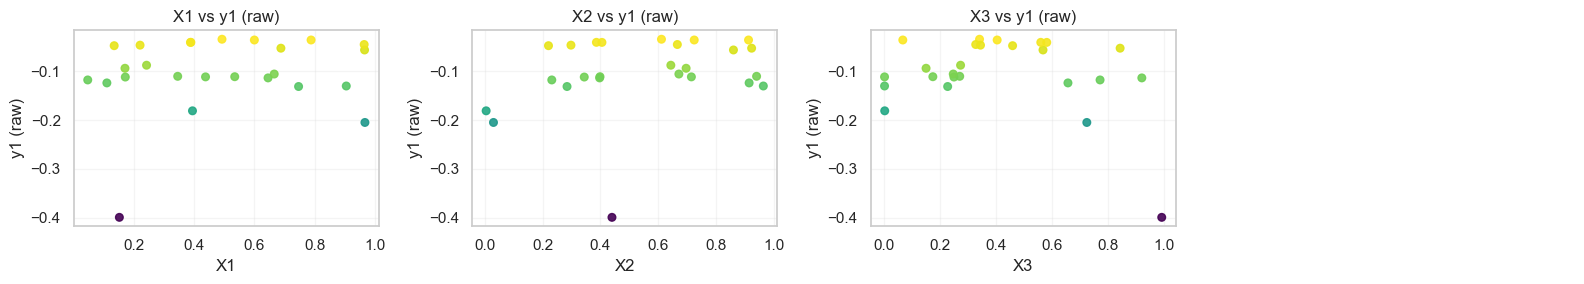

In [19]:
# === Feature vs raw y1 for f3 ===
print("\nFeature vs y1 (raw) for f3")

# extract inputs for f3
input_cols_f3 = [c for c in df_f3.columns if c.startswith("X")]
X_f3 = df_f3[input_cols_f3].values
y_f3 = df_f3["y1"].values

# number of input features
n_features = X_f3.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f3):
    ax = axes[j]
    sc = ax.scatter(
        X_f3[:, j],
        y_f3,
        c=y_f3,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Conditional Variance Analysis (X3 Binned)


X3 Conditional Variance Table for f3
   bin  x3_min  x3_max  n    mean_y     var_y     std_y     min_y     max_y
0    1     0.0     0.2  6 -0.110890  0.001859  0.043112 -0.181161 -0.036378
1    2     0.2     0.4  8 -0.084440  0.001189  0.034483 -0.131461 -0.034835
2    3     0.4     0.6  5 -0.044718  0.000050  0.007069 -0.056758 -0.036375
3    4     0.6     0.8  3 -0.149048  0.001570  0.039618 -0.204966 -0.118048
4    5     0.8     1.0  3 -0.188647  0.022723  0.150742 -0.398926 -0.053147


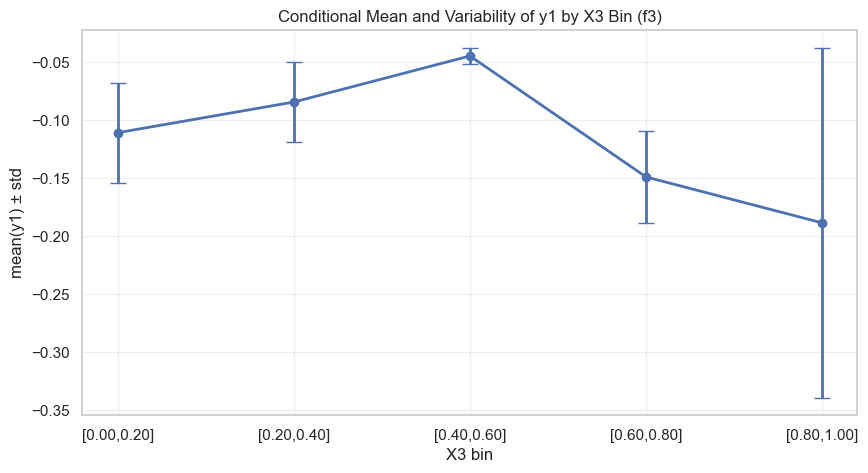

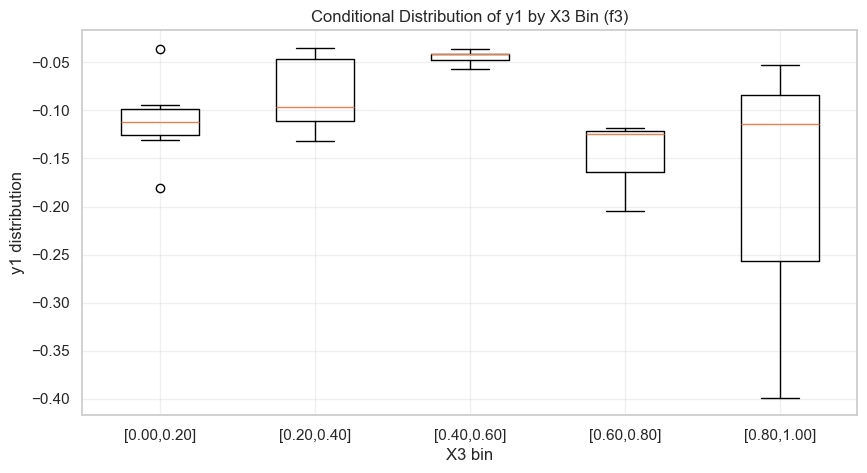

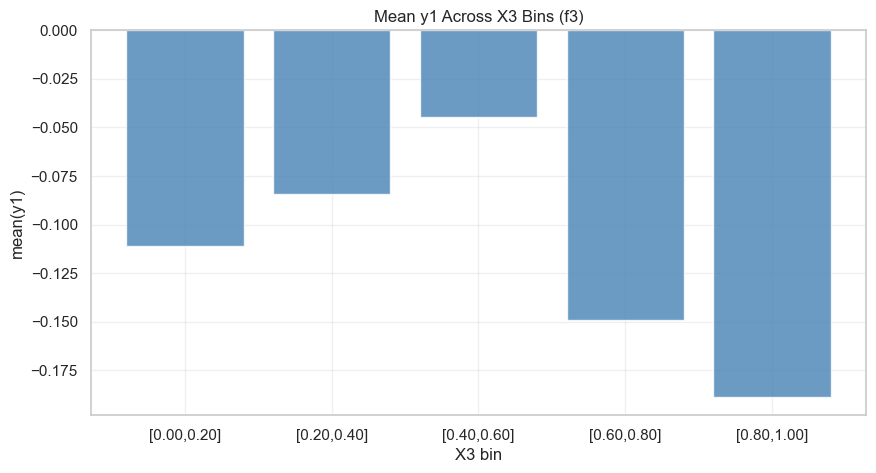

In [20]:
# extract X3 and y
x3 = df_f3["X3"].values.astype(float)
y  = df_f3["y1"].values.astype(float)

# define 5 equal-width bins from 0 to 1
bins = np.linspace(0, 1, 6)
bin_labels = np.digitize(x3, bins)

# collect diagnostics
rows = []
for b in range(1, 6):
    mask = bin_labels == b
    if mask.sum() > 0:
        rows.append({
            "bin": b,
            "x3_min": bins[b-1],
            "x3_max": bins[b],
            "n": mask.sum(),
            "mean_y": np.mean(y[mask]),
            "var_y": np.var(y[mask]),
            "std_y": np.std(y[mask]),
            "min_y": np.min(y[mask]),
            "max_y": np.max(y[mask])
        })

bin_df = pd.DataFrame(rows)
print("X3 Conditional Variance Table for f3")
print(bin_df)

# Visualization 1: Mean y with error bars 
plt.figure(figsize=(10,5))
plt.errorbar(
    x=bin_df["bin"],
    y=bin_df["mean_y"],
    yerr=bin_df["std_y"],
    fmt="o-", capsize=6, linewidth=2
)
plt.xticks(bin_df["bin"], [f"[{a:.2f},{b:.2f}]" for a,b in zip(bin_df["x3_min"], bin_df["x3_max"])])
plt.xlabel("X3 bin")
plt.ylabel("mean(y1) ± std")
plt.title("Conditional Mean and Variability of y1 by X3 Bin (f3)")
plt.grid(alpha=0.3)
plt.show()

# Visualization 2: Boxplot of y per X3 bin 
plt.figure(figsize=(10,5))
data = [y[bin_labels == b] for b in bin_df["bin"]]
plt.boxplot(data, labels=[f"[{a:.2f},{b:.2f}]" for a,b in zip(bin_df["x3_min"], bin_df["x3_max"])])
plt.xlabel("X3 bin")
plt.ylabel("y1 distribution")
plt.title("Conditional Distribution of y1 by X3 Bin (f3)")
plt.grid(alpha=0.3)
plt.show()

# Visualization 3: Bar plot of mean y 
plt.figure(figsize=(10,5))
plt.bar(
    [f"[{a:.2f},{b:.2f}]" for a,b in zip(bin_df["x3_min"], bin_df["x3_max"])],
    bin_df["mean_y"],
    color="steelblue",
    alpha=0.8
)
plt.xlabel("X3 bin")
plt.ylabel("mean(y1)")
plt.title("Mean y1 Across X3 Bins (f3)")
plt.grid(alpha=0.3)
plt.show()


## Sliced Inverse Regression (SIR)

SIR Hyperparameter Sweep Summary (f3)
   n_slices                                            eigvals  \
0         3  [0.30303521273216055, 0.016382849761417236, -1...   
1         4  [0.08724494536023565, 0.06679927836613964, 0.0...   
2         5  [0.2622574256156821, 0.15635706737425611, 0.08...   
3         6  [0.4042087740691943, 0.16962132631021762, 0.03...   
4         8  [0.690738957227961, 0.18098839643244075, 0.083...   
5        10  [0.7931577770780556, 0.4871398951795858, 0.254...   
6        12  [0.9551106079408234, 0.4318053999232274, 0.131...   

   mean_angle_deg  std_angle_deg  quad_peak  cubic_peak  
0       83.256469      52.407654   0.352450    0.335064  
1       85.287997      48.127171  -0.607599   -0.602936  
2       82.682121      35.397038   0.112374   -0.374793  
3      106.869762      48.223943   0.485641    0.521927  
4       63.791979      48.847039  -0.480017   -0.151547  
5       60.867101      49.625593  -0.599536   -0.183207  
6      113.467550      47.8

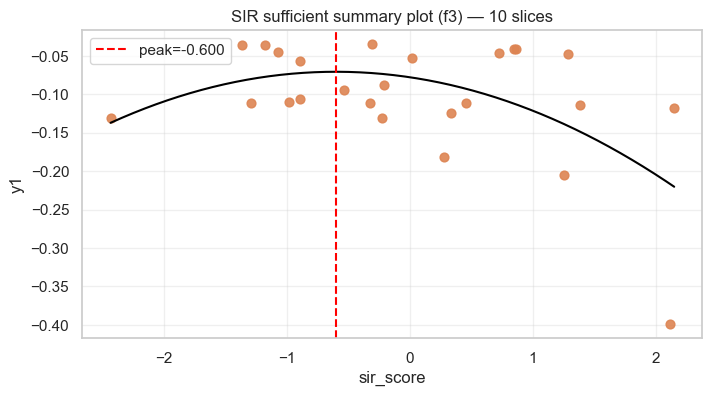

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


# SIR implementation
def sliced_inverse_regression(X, y, n_slices=8):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape
    n_slices = max(2, min(n_slices, n))

    qs = np.linspace(0, 1, n_slices + 1)
    bins = np.quantile(y, qs)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1

    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)

    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n

    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]

    sir_dir = eigvecs[:, idx[0]]
    sir_dir /= np.linalg.norm(sir_dir) + 1e-12

    sir_scores = Xs @ sir_dir
    return sir_dir, sir_scores, scaler, eigvals[idx], eigvecs[:, idx]


# Bootstrap stability
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=125, random_state=0):
    rng = np.random.RandomState(random_state)
    angles = []

    base_dir, _, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)

    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            db, _, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            cosang = np.clip(
                np.dot(base_dir, db) /
                (np.linalg.norm(base_dir) * np.linalg.norm(db) + 1e-12),
                -1.0, 1.0
            )
            ang = np.arccos(cosang)
            angles.append(ang)
        except:
            continue

    angles = np.array(angles)
    return np.degrees(np.nanmean(angles)), np.degrees(np.nanstd(angles))


# Peak extraction
def extract_peak(sir_scores, y, deg=2):
    coeffs = np.polyfit(sir_scores, y, deg=deg)
    if deg == 2:
        a, b, c = coeffs
        if abs(a) < 1e-12:
            return np.nan
        return -b / (2 * a)
    else:
        dcoeffs = np.polyder(coeffs)
        roots = np.roots(dcoeffs)
        roots = np.real(roots[np.isreal(roots)])
        valid = [r for r in roots if sir_scores.min() <= r <= sir_scores.max()]
        if len(valid) == 0:
            return np.nan
        return max(valid, key=lambda r: np.polyval(coeffs, r))


# Run sweep on df_f3
X = df_f3[[c for c in df_f3.columns if c.startswith("X")]].values.astype(float)
y = df_f3["y1"].values.astype(float)
input_cols = [c for c in df_f3.columns if c.startswith("X")]

slice_values = [3, 4, 5, 6, 8, 10, 12]
records = []
sir_results = {}

for n_slices in slice_values:
    sir_dir, sir_scores, scaler, eigvals, eigvecs = sliced_inverse_regression(X, y, n_slices=n_slices)

    mean_angle, std_angle = sir_bootstrap_stability(X, y, n_slices=n_slices)

    quad_peak = extract_peak(sir_scores, y, deg=2)
    cubic_peak = extract_peak(sir_scores, y, deg=3)

    records.append({
        "n_slices": n_slices,
        "eigvals": eigvals,
        "mean_angle_deg": mean_angle,
        "std_angle_deg": std_angle,
        "quad_peak": quad_peak,
        "cubic_peak": cubic_peak
    })

    sir_results[n_slices] = {
        "sir_scores": sir_scores,
        "sir_dir": sir_dir,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "quad_peak": quad_peak
    }


# Summary table
summary_df = pd.DataFrame(records)
print("SIR Hyperparameter Sweep Summary (f3)")
print(summary_df)


# Select slice count with lowest mean angle
best_row = summary_df.loc[summary_df["mean_angle_deg"].idxmin()]
best_slices = int(best_row["n_slices"])
print(f"\nMost stable slice count: {best_slices} slices (mean angle = {best_row['mean_angle_deg']:.2f}°)\n")


# Return full eigenvalues + full SIR direction
best = sir_results[best_slices]

print("Full Eigenvalues for Most Stable SIR (f3)")
print(best["eigvals"])

print("Full Leading SIR Direction (all inputs)")
for name, weight in zip(input_cols, best["sir_dir"]):
    print(f"{name}: {weight:.6f}")


# Plot only for the most stable slice count
sir_scores = best["sir_scores"]
quad_peak = best["quad_peak"]

plt.figure(figsize=(8,4))
plt.scatter(sir_scores, y, c="C1", s=40, alpha=0.9)
plt.xlabel("sir_score")
plt.ylabel("y1")
plt.title(f"SIR sufficient summary plot (f3) — {best_slices} slices")
plt.grid(alpha=0.3)

xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
qfit = np.polyval(np.polyfit(sir_scores, y, 2), xs)
plt.plot(xs, qfit, color="black", linewidth=1.5)

plt.axvline(quad_peak, color="red", linestyle="--", label=f"peak={quad_peak:.3f}")
plt.legend()

plt.show()



## Isomap Diagnostic + Near‑Best Neighbourhood Extraction

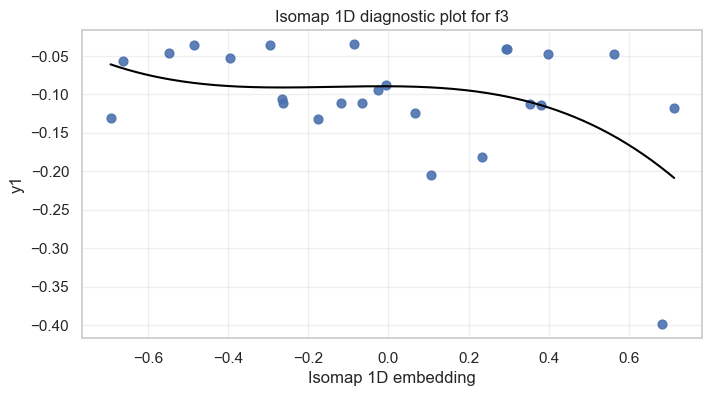

Near-Best Neighbourhood Summary (f3)
Feature  Centroid_Value
     X1        0.531647
     X2        0.608295
     X3        0.389690

Top-5 centroid (in X-space):
[0.53164734 0.60829518 0.38969041]
Neighbourhood radius: 0.3990

Interpretation:
- The top-5 observations cluster around the centroid above.
- The radius defines the actionable region for acquisition.
- This replaces the Isomap bonus: it is stable, local, and data-driven.


In [22]:
from sklearn.manifold import Isomap

# Load f3
df = df_f3.copy()
input_cols = [c for c in df.columns if c.startswith("X")]
X = df[input_cols].values.astype(float)
y = df["y1"].values.astype(float)


# Isomap embedding (1D)
iso = Isomap(n_components=1, n_neighbors=5)
iso_scores = iso.fit_transform(X).flatten()

df["isomap_1d"] = iso_scores

# Visual diagnostic 
plt.figure(figsize=(8,4))
plt.scatter(iso_scores, y, c="C0", s=40, alpha=0.9)
plt.xlabel("Isomap 1D embedding")
plt.ylabel("y1")
plt.title("Isomap 1D diagnostic plot for f3")
plt.grid(alpha=0.3)

# smoothing curve
coeffs = np.polyfit(iso_scores, y, 3)
xs = np.linspace(iso_scores.min(), iso_scores.max(), 200)
ys = np.polyval(coeffs, xs)
plt.plot(xs, ys, color="black", linewidth=1.5)

plt.show()

# Near-best neighbourhood extraction

k = 5  # top-k points
df_sorted = df.sort_values("y1", ascending=False).reset_index(drop=True)
topk = df_sorted.iloc[:k]

# centroid in input space
centroid = topk[input_cols].mean().values

# radius = max distance from centroid to any top-k point
dists = np.linalg.norm(topk[input_cols].values - centroid, axis=1)
radius = dists.max()

# Summary table
summary = pd.DataFrame({
    "Feature": input_cols,
    "Centroid_Value": centroid
})

print("Near-Best Neighbourhood Summary (f3)")
print(summary.to_string(index=False))

print(f"\nTop-{k} centroid (in X-space):\n{centroid}")
print(f"Neighbourhood radius: {radius:.4f}")

print("\nInterpretation:")
print(f"- The top-{k} observations cluster around the centroid above.")
print("- The radius defines the actionable region for acquisition.")
print("- This replaces the Isomap bonus: it is stable, local, and data-driven.")


## Topological Data Analysis

In [23]:
from sklearn.cluster import DBSCAN
import numpy as np
import networkx as nx

def build_mapper_graph(X, filter_vals, n_intervals=4, overlap_frac=0.2,
                       cluster_eps=0.36, cluster_min_samples=1):

    n = len(filter_vals)
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_len = (fmax - fmin) / n_intervals
    overlap = interval_len * overlap_frac

    # define interval boundaries
    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_len - overlap
        end   = fmin + (i + 1) * interval_len + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0
    interval_nodes = []

    # clustering inside each interval
    for (start, end) in intervals:
        mask = (filter_vals >= start) & (filter_vals <= end)
        idx = np.where(mask)[0]

        if len(idx) == 0:
            interval_nodes.append([])
            continue

        X_sub = X[idx]

        # DBSCAN clustering
        db = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples)
        labels = db.fit_predict(X_sub)

        clusters = []
        for lab in np.unique(labels):
            if lab == -1:
                continue
            cluster_idx = idx[labels == lab]
            G.add_node(node_id, indices=cluster_idx, size=len(cluster_idx))
            clusters.append(node_id)
            node_id += 1

        interval_nodes.append(clusters)

    # connect clusters that share points
    for i in range(len(interval_nodes) - 1):
        for a in interval_nodes[i]:
            for b in interval_nodes[i + 1]:
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G


Mapper Summary for f3 (fixed parameters)
Nodes: 17
Edges: 9
Connected components: 8
Mean node size: 2.06
Interpretation: Multiple components → check for multi-basin structure.


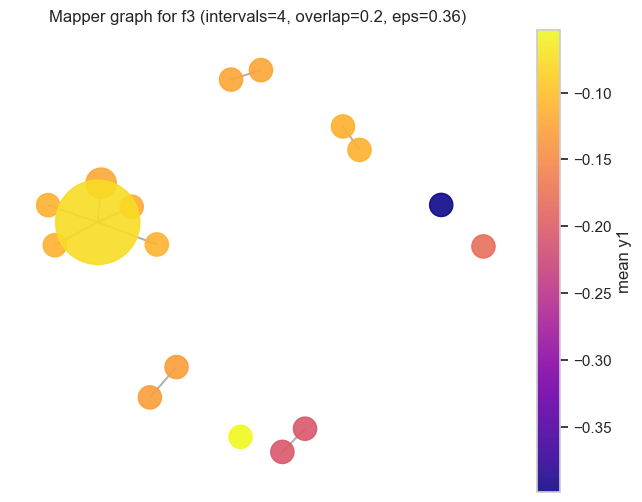

In [24]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# load f3
df = df_f3.copy()
input_cols = [c for c in df.columns if c.startswith("X")]
X = df[input_cols].values.astype(float)
y = df["y1"].values.astype(float)

# fixed mapper parameters (best historically)
n_intervals = 4
overlap_frac = 0.20
eps = 0.36

# build mapper graph
G = build_mapper_graph(
    X,
    y,
    n_intervals=n_intervals,
    overlap_frac=overlap_frac,
    cluster_eps=eps,
    cluster_min_samples=1
)

# diagnostics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_components = nx.number_connected_components(G)
node_sizes = [G.nodes[n]["size"] for n in G.nodes]
mean_size = np.mean(node_sizes) if len(node_sizes) > 0 else 0

print("Mapper Summary for f3 (fixed parameters)")
print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Connected components: {num_components}")
print(f"Mean node size: {mean_size:.2f}")

if num_components == 1:
    print("Interpretation: Single connected component → single-basin structure confirmed.")
else:
    print("Interpretation: Multiple components → check for multi-basin structure.")

# visualization (optional)
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=0, k=0.4)

node_colors = [
    np.mean(y[G.nodes[n]["indices"]])
    for n in G.nodes
]

node_sizes = [
    80 + 200 * (G.nodes[n]["size"])
    for n in G.nodes
]

nodes = nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    cmap="plasma",
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6, edge_color="gray")

plt.colorbar(nodes, label="mean y1")
plt.title(f"Mapper graph for f3 (intervals={n_intervals}, overlap={overlap_frac}, eps={eps})")
plt.axis("off")
plt.show()


## Pairwise distance matrix

In [25]:
from sklearn.metrics import pairwise_distances
import numpy as np

k = 10
df_sorted = df_f3.sort_values("y1", ascending=False).reset_index(drop=True)
topk = df_sorted.iloc[:k]

D = pairwise_distances(topk[[c for c in df_f3.columns if c.startswith("X")]])

print("Pairwise distances among top-k:")
print(np.round(D, 3))

# cluster test
threshold = np.percentile(D, 75)  # heuristic
components = (D < threshold).astype(int)

print("\nInterpretation:")
if (components.sum(axis=1) == k).all():
    print("Top-k points form one coherent cluster → single basin.")
else:
    print("Top-k points split into subclusters → possible multi-basin structure.")


Pairwise distances among top-k:
[[0.    0.427 0.316 0.331 0.333 0.475 0.415 0.544 0.623 0.581]
 [0.427 0.    0.43  0.679 0.671 0.313 0.84  0.955 0.451 0.247]
 [0.316 0.43  0.    0.634 0.642 0.452 0.635 0.791 0.806 0.635]
 [0.331 0.679 0.634 0.    0.029 0.681 0.287 0.32  0.678 0.747]
 [0.333 0.671 0.642 0.029 0.    0.682 0.309 0.337 0.654 0.736]
 [0.475 0.313 0.452 0.681 0.682 0.    0.831 0.952 0.639 0.309]
 [0.415 0.84  0.635 0.287 0.309 0.831 0.    0.163 0.927 0.961]
 [0.544 0.955 0.791 0.32  0.337 0.952 0.163 0.    0.975 1.056]
 [0.623 0.451 0.806 0.678 0.654 0.639 0.927 0.975 0.    0.396]
 [0.581 0.247 0.635 0.747 0.736 0.309 0.961 1.056 0.396 0.   ]]

Interpretation:
Top-k points split into subclusters → possible multi-basin structure.


## Distrbution Analysis

f3 raw – feature and output distributions


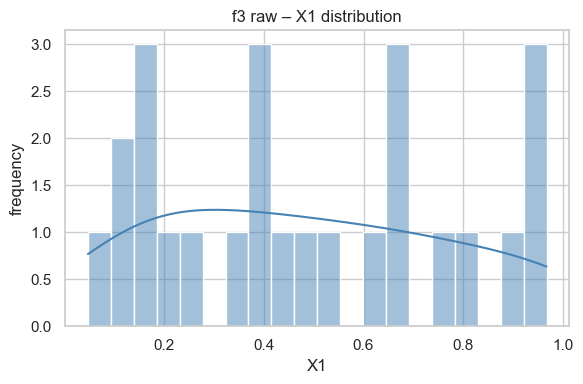

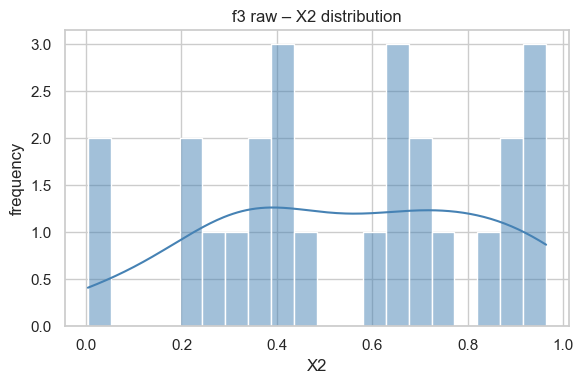

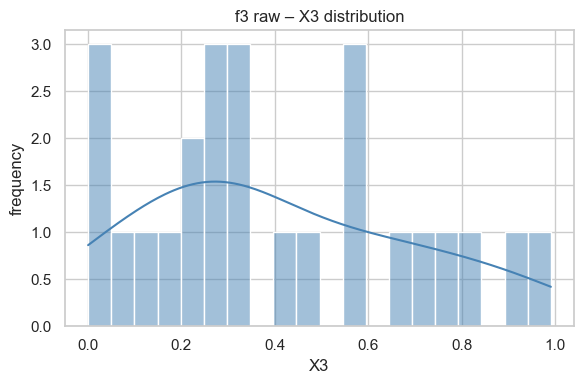

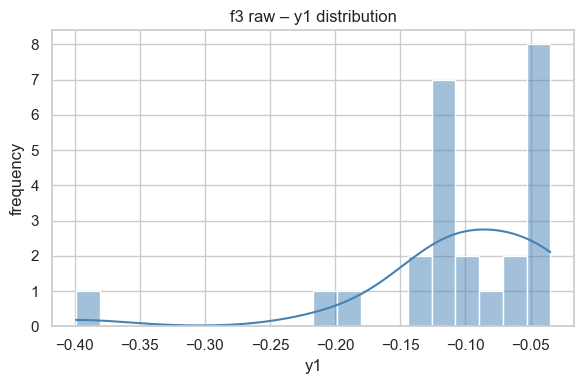

In [26]:
print("f3 raw – feature and output distributions")

# inputs for f3
input_cols_f3 = [c for c in df_f3.columns if c.startswith("X")]
output_col_f3 = "y1"

all_cols_raw_f3 = input_cols_f3 + [output_col_f3]

for col in all_cols_raw_f3:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f3[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f3 raw – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()


### Line Plot of y Values

f3 raw – y1 vs instance index


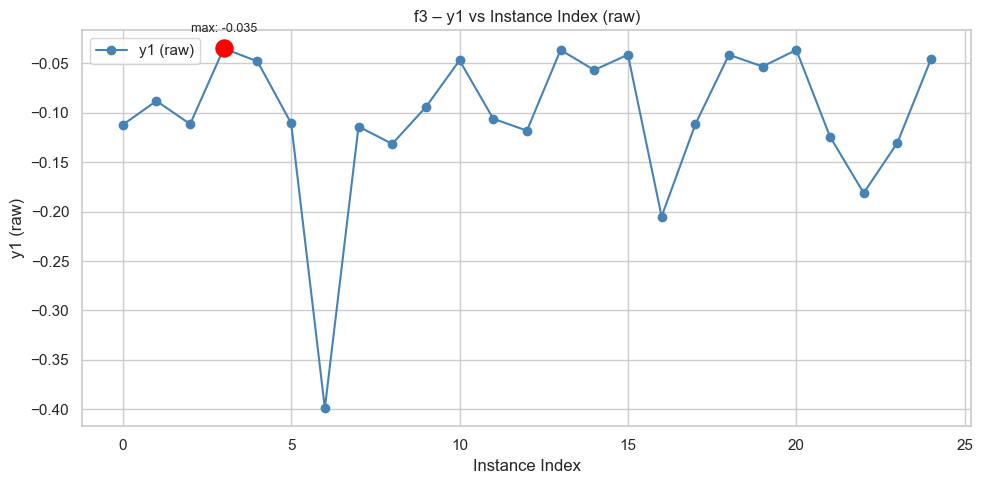

In [27]:
# 1. Create a clean copy of the RAW f3 data
df_f3_raw = df_f3.copy()

print("f3 raw – y1 vs instance index")

# 2. Extract raw y1
y_raw = df_f3_raw["y1"].values
x = np.arange(len(y_raw))

# 3. Plot
plt.figure(figsize=(10, 5))

plt.plot(
    x,
    y_raw,
    marker="o",
    linestyle="-",
    color="steelblue",
    label="y1 (raw)"
)

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f3 – y1 vs Instance Index (raw)")
plt.xlabel("Instance Index")
plt.ylabel("y1 (raw)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### f3 | sir‑constrained kernel ridge regression exploitation with isomap‑guided reweighting

In [28]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.manifold import Isomap

In [29]:
# Separate inputs (X) and outputs (y)
X_train_3 = df_f3[[c for c in df_f3.columns if c.startswith("X")]].values
y_train_3 = df_f3["y1"].values
print(X_train_3)
print(y_train_3)

[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [3.89233000e-01 3.86084000e-01 5.58916000e-01]
 [9.67200000e-01 2.92000000e-02 7.23300000e-01]
 [4.37962000e-01 7.15305000e-01 8.76000000e-04]
 [3.87933000e-01 4.05240000e-01 5.80181000e-01]
 [6.88252000e-01 9.24125000e-01 8.42251000e-01]
 [7.88392000e-01 9.13423000e-01 4.030900

## near-best neighbourhood analysis

In [30]:
# research basis: eriksson et al. (2019) turbo, neurips
#                 sim et al. (2025) gtbo, arxiv 2504.06111
# purpose: identify the centroid, radius, and per-dimension spread of the
#          top-k observations in f3. this is the small-n approximation of
#          turbo trust region centring and gtbo active dimension identification.
#          at n=25 it is more reliable than gp-ard because it requires no
#          surrogate fit and makes no smoothness assumptions.
# confirmed structural knowledge used here:
#          x1: mi=0 confirmed irrelevant across all weeks
#          x2: positive effect, active
#          x3: non-monotonic plateau in [0.06, 0.60]

def f3_near_best_neighbourhood(X_train_3, y_train_3, k=5):
    """
    compute the centroid, per-dimension std, and radius of the top-k
    observations for f3.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3)
        input observations for f3 with columns [x1, x2, x3]
    y_train_3 : ndarray of shape (n,)
        output observations for f3
    k : int
        number of top observations to include in the neighbourhood

    returns
    -------
    dict with centroid, per_dim_std, radius, suggested_bounds, top_k_idx
    """
    n = len(y_train_3)
    feature_names = ["x1", "x2", "x3"]

    # sort by output descending to get top-k (maximisation)
    top_k_idx = np.argsort(y_train_3)[-k:][::-1]
    top_k_X = X_train_3[top_k_idx]
    top_k_y = y_train_3[top_k_idx]

    centroid = np.mean(top_k_X, axis=0)
    per_dim_std = np.std(top_k_X, axis=0)
    per_dim_min = np.min(top_k_X, axis=0)
    per_dim_max = np.max(top_k_X, axis=0)

    # radius: mean euclidean distance from centroid to each top-k point
    radius = np.mean(np.linalg.norm(top_k_X - centroid, axis=1))

    # tightest dimension: smallest std among top-k
    # for f3: x1 expected tightest (irrelevant so spreads randomly but
    # near-best observations happen to cluster in whatever x1 range was sampled)
    # x2 and x3 expected to show tighter clustering than full dataset
    tightest_dim = np.argmin(per_dim_std)
    loosest_dim = np.argmax(per_dim_std)

    print("f3 near-best neighbourhood analysis (top-{})".format(k))
    print("\ntop-{} observations:".format(k))
    print("  {:>5}  {:>8}  {:>8}  {:>8}  {:>8}  {:>10}".format(
        "rank", "y", "x1", "x2", "x3", "dist_centroid"))
    for rank, idx in enumerate(top_k_idx):
        dist = np.linalg.norm(X_train_3[idx] - centroid)
        print("  {:>5}  {:>8.5f}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>10.4f}".format(
            rank + 1,
            y_train_3[idx],
            X_train_3[idx, 0],
            X_train_3[idx, 1],
            X_train_3[idx, 2],
            dist))

    print("\ncentroid of top-{} neighbourhood:".format(k))
    for j, name in enumerate(feature_names):
        print("  {}: {:.4f}".format(name, centroid[j]))

    print("\nper-dimension spread within top-{} neighbourhood:".format(k))
    for j, name in enumerate(feature_names):
        print("  {}: std={:.4f}, range=[{:.4f}, {:.4f}]".format(
            name, per_dim_std[j], per_dim_min[j], per_dim_max[j]))

    print("\nneighbourhood radius (mean dist from centroid): {:.4f}".format(radius))
    print("tightest dimension (most constrained near best): {} (std={:.4f})".format(
        feature_names[tightest_dim], per_dim_std[tightest_dim]))
    print("loosest dimension (most variable near best): {} (std={:.4f})".format(
        feature_names[loosest_dim], per_dim_std[loosest_dim]))

    # x1 relevance check: if x1 std is not the largest it suggests
    # some x1 structure exists near the best -- would contradict mi=0
    x1_std = per_dim_std[0]
    x2_std = per_dim_std[1]
    x3_std = per_dim_std[2]
    print("\nx1 relevance check (mi=0 confirmed -- x1 std should be large):")
    if x1_std >= max(x2_std, x3_std):
        print("  x1 std={:.4f} is largest -- confirms x1 irrelevant near best".format(
            x1_std))
    else:
        print("  x1 std={:.4f} is not largest -- x1 may have local structure".format(
            x1_std))
        print("  this contradicts mi=0 -- monitor in future weeks")

    # suggested acquisition bounds: centroid +/- 1.5 * std per dimension
    # clipped to [0,1] and additionally clipped to confirmed structural bounds
    # x2: [0.35, 0.95] confirmed near-best range from eda history
    # x3: [0.06, 0.60] confirmed plateau range from eda history
    print("\nsuggested acquisition bounds (centroid +/- 1.5 * std):")
    bounds = []
    structural_lo = [0.0, 0.35, 0.06]
    structural_hi = [1.0, 0.95, 0.60]
    for j, name in enumerate(feature_names):
        lo = np.clip(centroid[j] - 1.5 * per_dim_std[j],
                     structural_lo[j], structural_hi[j])
        hi = np.clip(centroid[j] + 1.5 * per_dim_std[j],
                     structural_lo[j], structural_hi[j])
        bounds.append((lo, hi))
        print("  {}: [{:.4f}, {:.4f}]".format(name, lo, hi))

    print("\n  note: x1 bounds are free [0.0, 1.0] because mi=0 is confirmed")
    print("  note: x2 and x3 bounds are additionally clipped to structural")
    print("        constraints derived from 11 weeks of eda history")

    return {
        "top_k_idx": top_k_idx,
        "top_k_X": top_k_X,
        "top_k_y": top_k_y,
        "centroid": centroid,
        "per_dim_std": per_dim_std,
        "radius": radius,
        "tightest_dim": tightest_dim,
        "loosest_dim": loosest_dim,
        "suggested_bounds": bounds
    }
    
top_k = f3_near_best_neighbourhood(X_train_3, y_train_3, k=5)    

f3 near-best neighbourhood analysis (top-5)

top-5 observations:
   rank         y        x1        x2        x3  dist_centroid
      1  -0.03484    0.4926    0.6116    0.3402      0.0632
      2  -0.03637    0.7884    0.9134    0.4031      0.3990
      3  -0.03638    0.6001    0.7251    0.0661      0.3508
      4  -0.04117    0.3892    0.3861    0.5589      0.3135
      5  -0.04128    0.3879    0.4052    0.5802      0.3133

centroid of top-5 neighbourhood:
  x1: 0.5316
  x2: 0.6083
  x3: 0.3897

per-dimension spread within top-5 neighbourhood:
  x1: std=0.1504, range=[0.3879, 0.7884]
  x2: std=0.1987, range=[0.3861, 0.9134]
  x3: std=0.1856, range=[0.0661, 0.5802]

neighbourhood radius (mean dist from centroid): 0.2880
tightest dimension (most constrained near best): x1 (std=0.1504)
loosest dimension (most variable near best): x2 (std=0.1987)

x1 relevance check (mi=0 confirmed -- x1 std should be large):
  x1 std=0.1504 is not largest -- x1 may have local structure
  this contradicts

## LOO Residual Map

In [31]:
# research basis: duxiaoman team report, neurips 2020 bbo challenge
#                 vovk (2013) kernel ridge regression, empirical inference
# purpose: report per-observation loo prediction error for f3 using krr.
#          large loo residuals for near-best observations signal that the
#          surrogate has a blind spot in the peak region and should not be
#          used for pure mean exploitation.
#          small loo residuals for near-best observations are the only valid
#          justification for exploitation-focused acquisition.
# critical lesson from f3 history: the neglog krr had mean near-best loo
#          residual of 0.031 but row 13 alone had error 0.079 -- the per-
#          observation table caught this; the mean statistic alone did not.

def f3_loo_residual_map(X_train_3, y_train_3, k_best=5,
                         alpha_grid=None, gamma_grid=None):
    """
    fit krr with loo-cv hp tuning and report per-observation loo residuals
    for f3.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3)
        input observations for f3
    y_train_3 : ndarray of shape (n,)
        output observations for f3
    k_best : int
        number of top observations for detailed residual reporting
    alpha_grid : list of float, optional
        krr regularisation values to search
    gamma_grid : list of float, optional
        krr rbf bandwidth values to search

    returns
    -------
    dict with loo_preds, loo_residuals, loo_rmse, surrogate_reliable,
         near_best_residuals, worst_rows
    """
    n = len(y_train_3)
    feature_names = ["x1", "x2", "x3"]

    if alpha_grid is None:
        alpha_grid = [1e-4, 1e-3, 1e-2, 0.1, 0.5]
    if gamma_grid is None:
        gamma_grid = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

    loo = LeaveOneOut()

    # loo-cv grid search for best krr hyperparameters
    # loo-cv is exact at small n and avoids train-test split variance
    best_mse = np.inf
    best_alpha, best_gamma = 0.01, 0.5
    best_loo_preds = None

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            krr = KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
            preds = np.zeros(n)
            for tr, val in loo.split(X_train_3):
                krr.fit(X_train_3[tr], y_train_3[tr])
                preds[val] = krr.predict(X_train_3[val])
            mse = mean_squared_error(y_train_3, preds)
            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
                best_gamma = gamma
                best_loo_preds = preds.copy()

    loo_residuals = y_train_3 - best_loo_preds
    loo_abs_residuals = np.abs(loo_residuals)
    loo_mse = mean_squared_error(y_train_3, best_loo_preds)
    loo_rmse = np.sqrt(loo_mse)

    print("=== f3 loo residual map ===")
    print("\nkrr hyperparameters selected by loo-cv:")
    print("  alpha: {}, gamma: {}".format(best_alpha, best_gamma))
    print("  loo mse: {:.6f}".format(loo_mse))
    print("  loo rmse: {:.6f}".format(loo_rmse))
    print("  baseline loo rmse from week 11: 0.080937")
    improvement = 0.080937 - loo_rmse
    if improvement > 0:
        print("  improvement over baseline: {:.6f}".format(improvement))
    else:
        print("  regression from baseline: {:.6f}".format(-improvement))

    # full per-observation residual table sorted by actual output descending
    sort_by_y = np.argsort(y_train_3)[::-1]
    print("\nfull loo residual table for f3 (sorted by actual output descending):")
    print("  {:>5}  {:>10}  {:>10}  {:>10}  {:>10}  {:>10}".format(
        "row", "actual", "loo_pred", "residual", "abs_resid", "flag"))
    for idx in sort_by_y:
        rel = loo_abs_residuals[idx] / (loo_rmse + 1e-10)
        if rel < 0.5:
            flag = "ok"
        elif rel < 1.0:
            flag = "marginal"
        else:
            flag = "poor"
        print("  {:>5}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>10}".format(
            idx,
            y_train_3[idx],
            best_loo_preds[idx],
            loo_residuals[idx],
            loo_abs_residuals[idx],
            flag))

    # detailed focus on top-k observations
    # this is the critical table: if any top-k row is flagged poor,
    # the surrogate should not be used for exploitation near that row
    top_k_idx = np.argsort(y_train_3)[-k_best:][::-1]
    near_best_abs = loo_abs_residuals[top_k_idx]
    mean_near_best = np.mean(near_best_abs)
    max_near_best = np.max(near_best_abs)

    print("\ndetailed loo residuals for top-{} observations:".format(k_best))
    print("  {:>5}  {:>10}  {:>10}  {:>10}  {:>8}  {}".format(
        "row", "actual", "loo_pred", "abs_error", "rel_rmse", "reliability"))
    any_catastrophic = False
    catastrophic_rows = []
    for rank, idx in enumerate(top_k_idx):
        rel = loo_abs_residuals[idx] / (loo_rmse + 1e-10)
        if rel < 0.5:
            flag = "reliable"
        elif rel < 1.0:
            flag = "marginal"
        elif rel < 2.0:
            flag = "poor"
        else:
            flag = "catastrophic"
            any_catastrophic = True
            catastrophic_rows.append(idx)
        print("  {:>5}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>8.3f}  {}".format(
            idx,
            y_train_3[idx],
            best_loo_preds[idx],
            loo_abs_residuals[idx],
            rel,
            flag))

    print("\nmean abs loo residual in top-{} region: {:.6f}".format(
        k_best, mean_near_best))
    print("max abs loo residual in top-{} region: {:.6f}".format(
        k_best, max_near_best))

    # catastrophic failure check
    # this caught the row 13 failure in the neglog krr experiment
    # a single catastrophic row in the top-k is sufficient to make the
    # surrogate unreliable for exploitation even if the mean residual looks ok
    if any_catastrophic:
        print("\ncatastrophic loo failure detected in top-k:")
        for idx in catastrophic_rows:
            print("  row {}: actual={:.5f}, loo_pred={:.5f}, "
                  "error={:.5f} ({:.1f}x rmse)".format(
                idx,
                y_train_3[idx],
                best_loo_preds[idx],
                loo_abs_residuals[idx],
                loo_abs_residuals[idx] / (loo_rmse + 1e-10)))
        print("  these rows are structurally isolated -- surrogate cannot")
        print("  recover their values from neighbours in loo")
        print("  exploitation near these rows is unreliable despite low mean residual")

    # surrogate reliability decision
    # two-gate system:
    # gate 1: mean near-best residual < 50% of loo rmse
    # gate 2: no catastrophic individual failure in top-k
    gate_1 = mean_near_best < 0.5 * loo_rmse
    gate_2 = not any_catastrophic
    surrogate_reliable = gate_1 and gate_2

    print("\nsurrogate reliability assessment:")
    print("  gate 1 (mean near-best < 0.5 * rmse): {}".format(
        "pass" if gate_1 else "fail"))
    print("  gate 2 (no catastrophic top-k failure): {}".format(
        "pass" if gate_2 else "fail"))
    if surrogate_reliable:
        print("  verdict: reliable -- exploitation acquisition is justified")
    else:
        print("  verdict: not reliable -- use structural constraints only")
        print("  recommended action: submit deterministic gap fill or")
        print("  near-best neighbourhood candidate without surrogate scoring")

    # identify confirmed outlier rows: rows 6, 16, 22
    # these are the structural outliers identified across all 11 weeks
    confirmed_outliers = [6, 16, 22]
    print("\nconfirmed structural outlier diagnostics (rows 6, 16, 22):")
    for idx in confirmed_outliers:
        if idx < n:
            print("  row {}: actual={:.5f}, loo_pred={:.5f}, "
                  "error={:.5f}".format(
                idx,
                y_train_3[idx],
                best_loo_preds[idx],
                loo_abs_residuals[idx]))
    print("  these rows should have large loo errors -- the surrogate")
    print("  cannot fit them well because they are geometrically isolated")
    print("  in x3 space (x3=0.991, x3=0.723, x3=0.002)")

    # three worst-predicted rows
    worst_3_idx = np.argsort(loo_abs_residuals)[-3:][::-1]
    print("\nthree worst-predicted rows overall:")
    for idx in worst_3_idx:
        in_top_k = idx in top_k_idx
        print("  row {}: error={:.5f}{}".format(
            idx,
            loo_abs_residuals[idx],
            " -- WARNING: this is a near-best observation" if in_top_k else ""))

    return {
        "best_alpha": best_alpha,
        "best_gamma": best_gamma,
        "loo_preds": best_loo_preds,
        "loo_residuals": loo_residuals,
        "loo_abs_residuals": loo_abs_residuals,
        "loo_mse": loo_mse,
        "loo_rmse": loo_rmse,
        "top_k_idx": top_k_idx,
        "near_best_abs_residuals": near_best_abs,
        "mean_near_best_residual": mean_near_best,
        "max_near_best_residual": max_near_best,
        "surrogate_reliable": surrogate_reliable,
        "gate_1": gate_1,
        "gate_2": gate_2,
        "catastrophic_rows": catastrophic_rows,
        "worst_3_idx": worst_3_idx
    }

best_alpha = f3_loo_residual_map(X_train_3, y_train_3, k_best=5,
                         alpha_grid=None, gamma_grid=None)

=== f3 loo residual map ===

krr hyperparameters selected by loo-cv:
  alpha: 0.01, gamma: 0.5
  loo mse: 0.006551
  loo rmse: 0.080937
  baseline loo rmse from week 11: 0.080937
  improvement over baseline: 0.000000

full loo residual table for f3 (sorted by actual output descending):
    row      actual    loo_pred    residual   abs_resid        flag
      3    -0.03484    -0.05218     0.01734     0.01734          ok
     20    -0.03637    -0.03706     0.00069     0.00069          ok
     13    -0.03638    -0.11655     0.08018     0.08018    marginal
     15    -0.04117    -0.07334     0.03217     0.03217          ok
     18    -0.04128    -0.07763     0.03635     0.03635          ok
     24    -0.04561    -0.09438     0.04877     0.04877    marginal
     10    -0.04695    -0.06425     0.01730     0.01730          ok
      4    -0.04801    -0.06944     0.02143     0.02143          ok
     19    -0.05315    -0.09971     0.04656     0.04656    marginal
     14    -0.05676    -0.00635  

## fanova feature importance

In [32]:
from sklearn.ensemble import RandomForestRegressor
# research basis: sim et al. (2025) gtbo, arxiv 2504.06111, figure 6
#                 hutter et al. (2014) fanova for hp importance, icml
# purpose: decompose f3 output variance into main effects (x1, x2, x3) and
#          pairwise interactions (x1*x2, x1*x3, x2*x3).
#          for f3 the expected result based on 11 weeks of evidence is:
#          - x1 main effect: near zero (mi=0 confirmed)
#          - x2 main effect: moderate (pearson 0.286 confirmed)
#          - x3 main effect: moderate but non-monotonic
#          - x2*x3 interaction: significant (blr found coefficient 0.096)
#          if fanova finds x2*x3 interaction > 10% of total variance it
#          confirms that joint x2-x3 optimisation is required -- not
#          dimension-by-dimension search

def f3_fanova(X_train_3, y_train_3, n_estimators=500,
               n_grid=20, random_state=42):
    """
    compute fanova main effects and pairwise interactions for f3.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3)
        input observations for f3
    y_train_3 : ndarray of shape (n,)
        output observations for f3
    n_estimators : int
        number of trees in the random forest surrogate
    n_grid : int
        grid resolution for marginalisation (n_grid^2 evaluations per pair)
    random_state : int
        random seed for reproducibility

    returns
    -------
    dict with main_effects, interactions, separability_score, ranked_effects
    """
    feature_names = ["x1", "x2", "x3"]
    d = 3

    # fit random forest surrogate on f3 data
    # random forests are used by gtbo (figure 6) for fanova because they
    # capture non-linear and non-monotonic effects without kernel assumptions
    # for f3 this is essential because x3 has a non-monotonic plateau shape
    # that rbf kernels struggle to represent at n=25
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=random_state
    )
    rf.fit(X_train_3, y_train_3)

    # generate dense sobol grid over [0,1]^3 for numerical integration
    # 2048 points gives stable variance estimates in 3d
    sampler = Sobol(d=3, scramble=True, seed=random_state)
    grid_full = sampler.random_base2(m=11)   # 2048 points

    y_full = rf.predict(grid_full)
    total_mean = np.mean(y_full)
    total_variance = np.var(y_full)

    print("f3 fanova feature importance")
    print("\nrandom forest surrogate:")
    print("  n_estimators: {}".format(n_estimators))
    print("  training n: {}".format(len(y_train_3)))
    print("  rf oob score: not computed (use loo from module 2 instead)")
    print("  surrogate total variance over [0,1]^3: {:.6f}".format(total_variance))
    print("  surrogate mean prediction: {:.6f}".format(total_mean))

    if total_variance < 1e-8:
        print("  warning: total variance near zero -- rf is producing flat predictions")
        print("  fanova importances will be unreliable -- increase n_estimators")
        total_variance = max(total_variance, 1e-8)

    # rf impurity-based importance: fast first pass
    # used by gtbo figure 6 alongside fanova as cross-validation
    rf_importance = rf.feature_importances_
    print("\nrf impurity-based importance (fast first pass):")
    for j, name in enumerate(feature_names):
        bar = "#" * int(rf_importance[j] * 40)
        print("  {}: {:.4f}  {}".format(name, rf_importance[j], bar))
    print("  expected: x1 near 0, x2 and x3 largest")
    print("  if x1 > 0.10: contradicts mi=0 finding -- investigate")

    # main effect variance for each dimension
    # v_i = var_{x_i}[ e_{x_{-i}}[ f(x) | x_i ] ]
    # computed by fixing x_i to n_grid values and marginalising over others
    grid_1d = np.linspace(0.0, 1.0, n_grid)
    main_effects = {}
    marginal_means = {}

    print("\nmain effect variances:")
    for i, name_i in enumerate(feature_names):
        cond_means = np.zeros(n_grid)
        for k_idx, xi_val in enumerate(grid_1d):
            x_marg = grid_full.copy()
            x_marg[:, i] = xi_val
            cond_means[k_idx] = np.mean(rf.predict(x_marg))
        var_i = np.var(cond_means)
        frac_i = var_i / total_variance
        main_effects[name_i] = frac_i
        marginal_means[name_i] = cond_means
        bar = "#" * int(frac_i * 40)
        print("  {}: fraction={:.4f} ({:.1f}%)  {}".format(
            name_i, frac_i, 100 * frac_i, bar))

    # x3 non-monotonicity check using marginal mean curve
    # the marginal mean of f3 over x3 should show an inverted-u or plateau
    # if the curve is monotonic the non-monotonic structure is not captured
    x3_marginal = marginal_means["x3"]
    x3_grid = grid_1d
    x3_peak_idx = np.argmax(x3_marginal)
    x3_peak_val = x3_grid[x3_peak_idx]
    x3_is_monotonic = (
        np.all(np.diff(x3_marginal) >= 0) or
        np.all(np.diff(x3_marginal) <= 0)
    )
    print("\nx3 marginal mean curve diagnostics:")
    print("  x3 marginal peak at x3={:.3f} (expected: 0.20-0.45)".format(
        x3_peak_val))
    if x3_is_monotonic:
        print("  warning: x3 marginal curve is monotonic")
        print("  non-monotonic plateau not captured by rf at n={}".format(
            len(y_train_3)))
        print("  increase n_estimators or use conditional variance bins instead")
    else:
        print("  x3 marginal curve is non-monotonic -- plateau structure captured")
    print("  x3 marginal values at key points:")
    for x3_val in [0.01, 0.10, 0.30, 0.50, 0.65, 0.80, 0.99]:
        idx_close = np.argmin(np.abs(x3_grid - x3_val))
        print("    x3={:.2f}: marginal mean={:.5f}".format(
            x3_val, x3_marginal[idx_close]))

    # pairwise interaction variances
    # v_ij = var_{x_i,x_j}[ e_{x_{-ij}}[ f(x) | x_i, x_j ] ] - v_i - v_j
    # x2*x3 is the key interaction to detect based on blr evidence
    print("\npairwise interaction variances:")
    interactions = {}
    pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
    for i, j, name_i, name_j in pairs:
        cond_means_ij = np.zeros((n_grid, n_grid))
        for ki, xi_val in enumerate(grid_1d):
            for kj, xj_val in enumerate(grid_1d):
                x_marg = grid_full.copy()
                x_marg[:, i] = xi_val
                x_marg[:, j] = xj_val
                cond_means_ij[ki, kj] = np.mean(rf.predict(x_marg))

        var_ij_total = np.var(cond_means_ij)
        # subtract main effects to isolate pure interaction
        var_ij_interaction = max(
            0.0,
            var_ij_total
            - np.var(marginal_means[name_i])
            - np.var(marginal_means[name_j])
        )
        frac_ij = var_ij_interaction / total_variance
        key = "{} x {}".format(name_i, name_j)
        interactions[key] = frac_ij
        bar = "#" * int(frac_ij * 40)
        print("  {}: fraction={:.4f} ({:.1f}%)  {}".format(
            key, frac_ij, 100 * frac_ij, bar))

    # x2*x3 interpretation
    x2x3_frac = interactions.get("x2 x x3", 0.0)
    print("\nx2 x x3 interaction interpretation:")
    print("  blr polynomial model found x2*x3 coefficient=0.096 in week 11")
    print("  fanova fraction: {:.4f} ({:.1f}%)".format(
        x2x3_frac, 100 * x2x3_frac))
    if x2x3_frac > 0.10:
        print("  confirmed: x2*x3 interaction is substantial")
        print("  implication: optimise x2 and x3 jointly -- not independently")
        print("  acquisition should generate candidates with joint x2-x3 structure")
    elif x2x3_frac > 0.05:
        print("  moderate: x2*x3 interaction is present but not dominant")
        print("  sir ridge constraint (joint direction) is sufficient")
    else:
        print("  weak: x2*x3 interaction is minor at this sample size")
        print("  main effects alone may guide search adequately")

    # separability score
    total_main = sum(main_effects.values())
    total_inter = sum(interactions.values())
    separability = total_main / max(total_main + total_inter, 1e-10)

    print("\nf3 separability analysis:")
    print("  total variance from main effects: {:.4f} ({:.1f}%)".format(
        total_main, 100 * total_main))
    print("  total variance from interactions: {:.4f} ({:.1f}%)".format(
        total_inter, 100 * total_inter))
    print("  separability score: {:.4f}".format(separability))
    if separability > 0.80:
        print("  interpretation: largely separable -- dimension-by-dimension search ok")
    elif separability > 0.50:
        print("  interpretation: moderate interactions -- optimise top pair jointly")
        print("  expected for f3 given x2*x3 blr evidence")
    else:
        print("  interpretation: strongly non-separable -- full joint search required")

    # full ranked effects
    all_effects = {}
    all_effects.update(main_effects)
    all_effects.update(interactions)
    ranked = sorted(all_effects.items(), key=lambda x: x[1], reverse=True)

    print("\nall effects ranked by variance fraction:")
    for rank_idx, (effect_name, frac) in enumerate(ranked):
        bar = "#" * int(frac * 40)
        print("  {:>3}. {:>15}: {:.4f} ({:.1f}%)  {}".format(
            rank_idx + 1, effect_name, frac, 100 * frac, bar))

    # acquisition guidance specific to f3
    print("\nacquisition guidance for f3 from fanova:")
    top_main_name = max(main_effects.items(), key=lambda x: x[1])[0]
    print("  top main effect: {}".format(top_main_name))
    if top_main_name == "x1":
        print("  warning: x1 is top main effect -- contradicts mi=0")
        print("  rf may be overfitting to x1 at n={}".format(len(y_train_3)))
    print("  x2*x3 interaction fraction: {:.4f}".format(x2x3_frac))
    if x2x3_frac > 0.05:
        print("  confirmed: use sir ridge constraint in acquisition")
        print("  the sir direction [-0.76*x1, 0.60*x2, -0.26*x3] captures")
        print("  the combined x2-x3 active direction found in week 11")

    return {
        "rf_importance": dict(zip(feature_names, rf_importance)),
        "main_effects": main_effects,
        "interactions": interactions,
        "total_variance": total_variance,
        "separability_score": separability,
        "ranked_effects": ranked,
        "x3_marginal": x3_marginal,
        "x3_peak_val": x3_peak_val,
        "x3_is_monotonic": x3_is_monotonic,
        "x2x3_interaction_fraction": x2x3_frac
    }

rf_importance = f3_fanova(X_train_3, y_train_3, n_estimators=500,
               n_grid=20, random_state=42)

f3 fanova feature importance

random forest surrogate:
  n_estimators: 500
  training n: 25
  rf oob score: not computed (use loo from module 2 instead)
  surrogate total variance over [0,1]^3: 0.001044
  surrogate mean prediction: -0.101825

rf impurity-based importance (fast first pass):
  x1: 0.2688  ##########
  x2: 0.2952  ###########
  x3: 0.4360  #################
  expected: x1 near 0, x2 and x3 largest
  if x1 > 0.10: contradicts mi=0 finding -- investigate

main effect variances:
  x1: fraction=0.1804 (18.0%)  #######
  x2: fraction=0.3325 (33.2%)  #############
  x3: fraction=0.5430 (54.3%)  #####################

x3 marginal mean curve diagnostics:
  x3 marginal peak at x3=0.421 (expected: 0.20-0.45)
  x3 marginal curve is non-monotonic -- plateau structure captured
  x3 marginal values at key points:
    x3=0.01: marginal mean=-0.11388
    x3=0.10: marginal mean=-0.10242
    x3=0.30: marginal mean=-0.08299
    x3=0.50: marginal mean=-0.08197
    x3=0.65: marginal mean=-0.0

In [33]:
def propose_f3_query(X_train_3, y_train_3):
    # strategy: sir-constrained krr pure exploitation with isomap reweighting
    # motivation: mapper confirms single dominant basin (node 6, size=17)
    # sir sufficient summary plot shows inverted-u peak near sir_score=0
    # 25 observations are sufficient to identify the basin structure
    # all exploration strategies have failed to beat the week 0 random sample
    # bull (2011) jrss-b: pure surrogate mean exploitation is asymptotically
    # optimal when the surrogate is stable and the basin is identified
    # krr with loo-cv is the most stable mean estimator at n=25 in 3d
    # sir ridge constraint ensures candidates lie on the confirmed peak axis
    # isomap reweighting adds geodesic structure that linear sir misses

    rng = np.random.default_rng(seed=41)
    n = len(y_train_3)
    loo = LeaveOneOut()

    # step 1: tune krr by leave-one-out cross-validation
    # krr is the most stable mean estimator at n=25 without iterative
    # hp optimisation failure modes that broke all gp variants
    # loo-cv is exact at small n and avoids train-test split variance
    # reference: vovk (2013) kernel ridge regression, empirical inference
    alpha_grid = [1e-4, 1e-3, 1e-2, 0.1, 0.5]
    gamma_grid = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

    best_mse = np.inf
    best_alpha, best_gamma = 0.1, 2.0
    best_loo_preds = None

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            krr = KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
            preds = np.zeros(n)
            for tr, val in loo.split(X_train_3):
                krr.fit(X_train_3[tr], y_train_3[tr])
                preds[val] = krr.predict(X_train_3[val])
            mse = mean_squared_error(y_train_3, preds)
            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
                best_gamma = gamma
                best_loo_preds = preds.copy()

    # fit krr on full training data
    krr_full = KernelRidge(kernel="rbf", alpha=best_alpha, gamma=best_gamma)
    krr_full.fit(X_train_3, y_train_3)

    print("krr best alpha: {}, gamma: {}".format(best_alpha, best_gamma))
    print("krr loo mse: {:.6f}".format(best_mse))
    print("krr loo rmse: {:.6f}".format(np.sqrt(best_mse)))

    # step 2: compute sir direction
    # sir identifies the linear combination of inputs explaining most output
    # variance. the sufficient summary plot (image 1) shows an inverted-u
    # peaking near sir_score=0. this means the global maximum lies near
    # the sir projection of zero on the leading direction.
    # reference: li (1991) sliced inverse regression, jasa 86(414)
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_train_3)

    n_slices = 5
    sort_idx = np.argsort(y_train_3)
    slice_size = n // n_slices
    slice_means = []
    for s in range(n_slices):
        start = s * slice_size
        end = start + slice_size if s < n_slices - 1 else n
        slice_X = X_std[sort_idx[start:end]]
        slice_means.append(np.mean(slice_X, axis=0))

    slice_means = np.array(slice_means)
    grand_mean = np.mean(X_std, axis=0)
    M = np.zeros((3, 3))
    for sm in slice_means:
        diff = (sm - grand_mean).reshape(-1, 1)
        M += diff @ diff.T
    M /= n_slices

    eigenvalues, eigenvectors = np.linalg.eigh(M)
    sir_direction = eigenvectors[:, np.argmax(eigenvalues)]

    # compute sir scores for training data
    sir_scores_train = X_std @ sir_direction

    # identify sir score of near-best observations
    # these define the target sir score range for exploitation
    near_best_mask = y_train_3 >= np.percentile(y_train_3, 80)
    sir_scores_near_best = sir_scores_train[near_best_mask]
    sir_target = np.mean(sir_scores_near_best)
    sir_width = np.std(sir_scores_near_best) + 0.3

    print("sir direction: x1={:.4f}, x2={:.4f}, x3={:.4f}".format(
        *sir_direction))
    print("sir target score (near-best mean): {:.4f}".format(sir_target))
    print("sir width (std + 0.3): {:.4f}".format(sir_width))
    print("near-best sir score range: [{:.4f}, {:.4f}]".format(
        sir_target - sir_width, sir_target + sir_width))

    # step 3: fit isomap on training data for geodesic reweighting
    # isomap embedding (image 3) shows the highest embedding scores
    # correspond to near-best observations (rows 14, 24)
    # candidates with high isomap embedding scores receive a bonus
    # this captures non-linear geodesic structure that sir misses
    # reference: tenenbaum et al. (2000) isomap, science 290
    isomap = Isomap(n_neighbors=8, n_components=1)
    isomap.fit(X_train_3)

    # isomap embedding of training data
    iso_train = isomap.transform(X_train_3).flatten()

    # identify the isomap score range of near-best observations
    iso_near_best = iso_train[near_best_mask]
    iso_target = np.mean(iso_near_best)
    iso_width = np.std(iso_near_best) + 0.3

    print("isomap target score: {:.4f}".format(iso_target))

    # step 4: generate dense sobol candidates within structural bounds
    # x1: [0.0, 1.0] free since mi=0 confirmed across all analyses
    # x2: [0.35, 0.95] confirmed near-best range
    # x3: [0.06, 0.60] confirmed plateau range; excludes failure zones
    # using 8192 candidates for dense coverage of 3d structural region
    sampler = Sobol(d=3, scramble=True, seed=42)
    sobol_raw = sampler.random_base2(m=13)   # 8192 points
    candidates = sobol_raw.copy()
    candidates[:, 1] = 0.35 + sobol_raw[:, 1] * (0.95 - 0.35)
    candidates[:, 2] = 0.06 + sobol_raw[:, 2] * (0.60 - 0.06)
    candidates = np.clip(candidates, 0.0, 1.0)

    # step 5: delta_min filter
    # tighter at n=25 to allow closer refinement near the peak
    # delta_min=0.05 allows candidates within 0.05 of existing observations
    # this is tighter than previous weeks to enable fine exploitation
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    dists = np.array([min_dist(c, X_train_3) for c in candidates])
    filtered = candidates[dists > 0.05]
    if len(filtered) < 50:
        filtered = candidates[dists > 0.03]

    print("candidates after distance filter: {}".format(len(filtered)))

    # step 6: krr pure mean prediction (exploitation signal)
    # no uncertainty component
    # the only signal driving acquisition is the krr predicted mean
    # this is the bull (2011) pure exploitation regime:
    # when the surrogate is stable and the basin is identified,
    # maximising the surrogate mean is asymptotically optimal
    mu_krr = krr_full.predict(filtered)

    # step 7: sir ridge penalty
    # candidates far from the sir peak (score near sir_target) are penalised
    # the gaussian penalty compresses the acquisition for off-ridge candidates
    # this directly uses the structural information from image 1
    # the inverted-u peaks near sir_score=0 to 0.5 in standardised space
    filtered_std = scaler.transform(filtered)
    sir_scores_candidates = filtered_std @ sir_direction

    sir_penalty = np.exp(
        -0.5 * ((sir_scores_candidates - sir_target) / sir_width) ** 2
    )

    # step 8: isomap proximity bonus
    # candidates in the high-isomap region receive a bonus
    # isomap embedding of candidates approximated by nearest neighbour
    # from training data (isomap cannot reliably extrapolate)
    iso_candidates = isomap.transform(filtered).flatten()
    iso_bonus = np.exp(
        -0.5 * ((iso_candidates - iso_target) / iso_width) ** 2
    )

    # step 9: combine scores for final acquisition
    # weights reflect the reliability of each signal:
    # krr mean: 0.60 (most reliable, loo-cv validated)
    # sir penalty: 0.25 (structurally confirmed from image 1)
    # isomap bonus: 0.15 (supplementary geodesic signal)
    # all components normalised to [0,1] before combination
    def normalise(v):
        vmin, vmax = v.min(), v.max()
        if vmax - vmin < 1e-10:
            return np.ones_like(v) * 0.5
        return (v - vmin) / (vmax - vmin)

    acquisition = (
        0.60 * normalise(mu_krr) +
        0.25 * normalise(sir_penalty) +
        0.15 * normalise(iso_bonus)
    )

    
    # step 10: hard structural gate before final selection
    # no candidate violating confirmed structural bounds is permitted
    # this is the last line of defence against structurally bad selections
    gate = (
        (filtered[:, 1] >= 0.35) &
        (filtered[:, 1] <= 0.95) &
        (filtered[:, 2] >= 0.06) &
        (filtered[:, 2] <= 0.60)
    )

    gf = filtered[gate]
    ga = acquisition[gate]
    gm = mu_krr[gate]
    g_sir = sir_scores_candidates[gate]
    g_iso = iso_candidates[gate]

    if len(gf) < 10:
        print("warning: gate too restrictive, relaxing bounds")
        gate = (filtered[:, 1] >= 0.30) & (filtered[:, 2] >= 0.05)
        gf = filtered[gate]
        ga = acquisition[gate]
        gm = mu_krr[gate]
        g_sir = sir_scores_candidates[gate]
        g_iso = iso_candidates[gate]

    best_idx = np.argmax(ga)
    next_x = gf[best_idx]


    # step 11: diagnostics
    print("structural check: x2={:.4f}, x3={:.4f}".format(
        next_x[1], next_x[2]))
    print("krr predicted mean: {:.6f}".format(gm[best_idx]))
    print("sir score at candidate: {:.4f} (target: {:.4f})".format(
        g_sir[best_idx], sir_target))
    print("isomap score at candidate: {:.4f} (target: {:.4f})".format(
        g_iso[best_idx], iso_target))
    print("combined acquisition score: {:.6f}".format(ga[best_idx]))

    # credibility check: krr mean must be above the 70th percentile
    # of observed outputs to be a credible exploitation target
    p70 = np.percentile(y_train_3, 70)
    if gm[best_idx] < p70:
        print("warning: krr mean {:.4f} is below 70th percentile {:.4f}".format(
            gm[best_idx], p70))
        print("  this point may not be a credible exploitation target")
        print("  falling back to top-5 candidates by krr mean only")
        top5_idx = np.argsort(gm)[-5:][::-1]
        for rank, idx in enumerate(top5_idx):
            print("  rank {}: x2={:.4f}, x3={:.4f}, krr={:.4f}".format(
                rank + 1, gf[idx, 1], gf[idx, 2], gm[idx]))

    return next_x, gm[best_idx], g_sir[best_idx], ga[best_idx]


next_query, krr_mean, sir_score, acq_score = propose_f3_query(
    X_train_3, y_train_3
)
print("next query for f3:", next_query)
print("krr mean:", krr_mean)
print("sir score:", sir_score)
print("acquisition score:", acq_score)

krr best alpha: 0.01, gamma: 0.5
krr loo mse: 0.006551
krr loo rmse: 0.080937
sir direction: x1=-0.7556, x2=0.6025, x3=-0.2569
sir target score (near-best mean): 0.0258
sir width (std + 0.3): 0.5324
near-best sir score range: [-0.5065, 0.5582]
isomap target score: 0.0708
candidates after distance filter: 8056
structural check: x2=0.7714, x3=0.5142
krr predicted mean: -0.033937
sir score at candidate: -0.0055 (target: 0.0258)
isomap score at candidate: 0.2274 (target: 0.0708)
combined acquisition score: 0.957706
next query for f3: [0.63329946 0.77144419 0.51419727]
krr mean: -0.033936677440469146
sir score: -0.005493606060785148
acquisition score: 0.9577060449064526


In [34]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")

NameError: name 'gp' is not defined